In [229]:
import torch
from torch import nn 
from torchvision import datasets
from torch.utils.data import DataLoader , TensorDataset

In [230]:
import random
import torch
import numpy as np
from PIL import Image, ImageDraw
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLASS_NAMES = {0: "Background", 1: "Rectangle", 2: "Circle", 3: "Triangle"}

class ShapeDataset(Dataset):
    def __init__(self, size=200, image_size=128, max_objects=3):
        self.size = size
        self.image_size = image_size
        self.max_objects = max_objects

    def __len__(self):
        return self.size

    def __getitem__(self, index):
        random.seed(index)
        np.random.seed(index)

        image = np.random.randint(180, 256, (self.image_size, self.image_size, 3), dtype=np.uint8)
        image = Image.fromarray(image)
        draw = ImageDraw.Draw(image)

        boxes = []
        labels = []

        num_objects = random.randint(1, self.max_objects)

        for _ in range(num_objects):
            cls = random.randint(1, 3)
            w = random.randint(20, 45)
            h = random.randint(20, 45)
            xmin = random.randint(0, self.image_size - w - 1)
            ymin = random.randint(0, self.image_size - h - 1)
            xmax = xmin + w
            ymax = ymin + h

            color = tuple(random.randint(20, 230) for _ in range(3))

            if cls == 1:
                draw.rectangle([xmin, ymin, xmax, ymax], fill=color)
            elif cls == 2:
                draw.ellipse([xmin, ymin, xmax, ymax], fill=color)
            else:
                points = [(xmin + w // 2, ymin), (xmin, ymax), (xmax, ymax)]
                draw.polygon(points, fill=color)

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(cls)

        image = np.array(image, dtype=np.float32)
        noise = np.random.normal(0, 20, image.shape)
        image = np.clip(image + noise, 0, 255)

        image = torch.tensor(image, dtype=torch.float32) / 255.0
        image = image.permute(2, 0, 1)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.long)
        }

        return image, target

def show_sample(image, boxes, labels):
    image = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box

        plt.gca().add_patch(
            patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                linewidth=2
            )
        )

        plt.text(
            xmin,
            ymin,
            CLASS_NAMES[int(label)],
            color="white",
            backgroundcolor="black"
        )

    plt.axis("off")
    plt.show()

Labels: tensor([1, 2, 1])
Boxes:
 tensor([[ 73.,   1., 106.,  36.],
        [ 20.,   4.,  48.,  44.],
        [ 46.,   5.,  73.,  48.]])
50


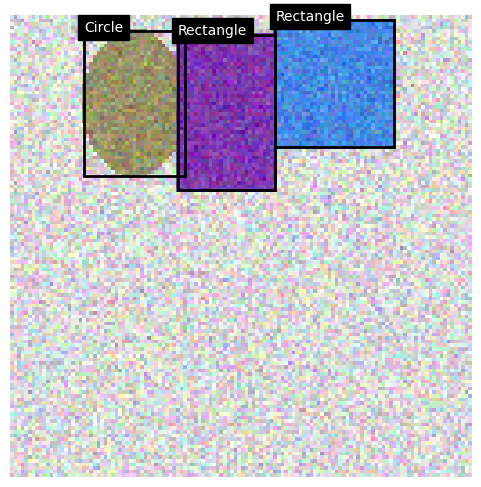

In [231]:
dataset = ShapeDataset(size=50, image_size=128, max_objects=3)

img_tensor, target_dict = dataset[10]

print("Labels:", target_dict["labels"])
print("Boxes:\n", target_dict["boxes"])
print(len(dataset))

show_sample(img_tensor, target_dict["boxes"], target_dict["labels"])


In [232]:
def IoU(box1, box2):
    x1 = torch.max(box1[0], box2[0])
    y1 = torch.max(box1[1], box2[1])
    
    x2 = torch.min(box1[2], box2[2])
    y2 = torch.min(box1[3], box2[3])
    
    inter_w = torch.clamp(x2 - x1, min=0)
    inter_h = torch.clamp(y2 - y1, min=0)
    
    inter = inter_w * inter_h
    
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union = box1_area + box2_area - inter
    
    IoU = inter / union
    
    return IoU


In [233]:
import selectivesearch
import cv2
import numpy as np

def selective_search(image):

    image = image.permute(1, 2, 0)
    image = image.numpy()

    image = (image * 255).astype(np.uint8)

    _, regions = selectivesearch.selective_search(
        image,
        scale=70,
        sigma=1.75,
        min_size=50
    )

    proposals = []

    for region in regions:

        x, y, w, h = region["rect"]

        if w < 30 or h < 30:
            continue

        proposals.append([
            x,
            y,
            x + w,
            y + h
        ])

    return proposals


In [234]:
def prepare_proposals(proposals, gt_boxes, gt_labels, threshold=0.4):

    final_boxes = []
    final_labels = []

    proposals = torch.tensor(proposals, dtype=torch.float32)
    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)

    for proposal in proposals:

        best_iou = 0
        best_gt_index = -1

        for i, gt_box in enumerate(gt_boxes):

            iou = IoU(proposal, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_index = i


        if best_iou >= threshold:
            label = gt_labels[best_gt_index]

        else:
            label = 0


        final_boxes.append(proposal)
        final_labels.append(label)


    return {
        "boxes": torch.stack(final_boxes),
        "labels": torch.tensor(final_labels)
    }
    


GT:
{'boxes': tensor([[ 31.,  60.,  62., 100.],
        [ 86.,  71., 116.,  98.]]), 'labels': tensor([2, 3])}
Proposals:
{'boxes': tensor([[  0.,   0., 127., 127.],
        [ 31.,  59.,  62., 101.],
        [ 84.,  65., 119., 102.],
        [ 29.,  57.,  62., 104.],
        [ 29.,  57.,  62., 104.],
        [ 84.,  65., 119., 102.],
        [  0.,   0., 127., 127.],
        [  0.,   0., 127., 127.],
        [  0.,   0., 127., 127.]]), 'labels': tensor([0, 2, 3, 2, 2, 3, 0, 0, 0])}


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20776\828917432.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)


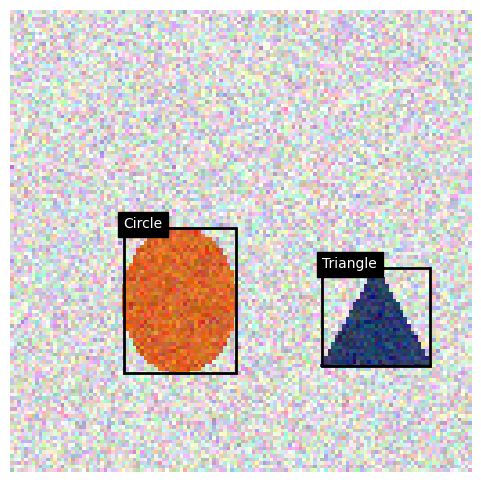

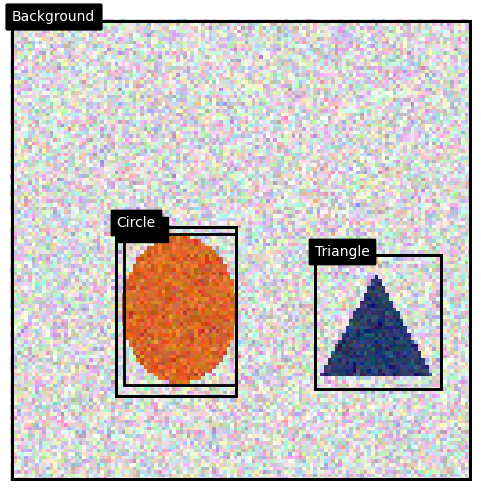

In [235]:
image, target = dataset[50]

proposals = selective_search(image)

best_proposals = prepare_proposals(
    proposals,
    target["boxes"],
    target["labels"]
)

print("GT:")
print(target)

print("Proposals:")
print(best_proposals)

show_sample(
    image,
    target["boxes"],
    target["labels"]
)

show_sample(
    image,
    best_proposals["boxes"],
    best_proposals["labels"]
)

In [236]:
import cv2

def crop(image, boxes, labels):

    if torch.is_tensor(image):
        image = image.permute(1,2,0).numpy()

    crop_images = []
    crop_labels = []

    for i in range(len(boxes)):

        box = boxes[i]

        xmin = int(box[0])
        ymin = int(box[1])
        xmax = int(box[2])
        ymax = int(box[3])

        crop_image = image[ymin:ymax, xmin:xmax]

        crop_image = cv2.resize(
            crop_image,
            (28,28)
        )

        crop_images.append(crop_image)
        crop_labels.append(labels[i])

    return crop_images, crop_labels

In [237]:
X = []
y = []

for i in range(len(dataset)):

    image, target = dataset[i]
    
    proposals = selective_search(image)

    best_proposals = prepare_proposals(
        proposals,
        target["boxes"],
        target["labels"]
    )
    
    crop_images, crop_labels = crop(
        image,
        best_proposals["boxes"],
        best_proposals["labels"]
    )
    
    X.extend(crop_images)
    y.extend(crop_labels)
    

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20776\828917432.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)


In [238]:
import torch
from torch import nn

class RCNN_CNN(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),     # 28 -> 14


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),     # 14 -> 7


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*7*7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)

        )


    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [239]:
X = [
    torch.tensor(img, dtype=torch.float32).permute(2,0,1)
    for img in X
]

X = torch.stack(X)
y = torch.tensor(y)

print(X.shape)
print(y.shape)

torch.Size([684, 3, 28, 28])
torch.Size([684])


In [240]:
from sklearn.model_selection import train_test_split


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [241]:
from torch.utils.data import TensorDataset, DataLoader


train_ds = TensorDataset(
    X_train,
    y_train
)

val_ds = TensorDataset(
    X_val,
    y_val
)


train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)


val_loader = DataLoader(
    val_ds,
    batch_size=32
)

In [242]:
device = "cuda" if torch.cuda.is_available() else "cpu"


model = RCNN_CNN().to(device)


criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [243]:
epochs = 20

train_accs = []
val_accs = []

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        pred = model(X_batch)

        loss = criterion(
            pred,
            y_batch
        )


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        total_loss += loss.item()


        correct += (
            pred.argmax(1)==y_batch
        ).sum().item()

        total += y_batch.size(0)



    train_acc = correct / total
    train_accs.append(train_acc)



    # validation

    model.eval()

    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            pred = model(X_batch)


            val_correct += (
                pred.argmax(1)==y_batch
            ).sum().item()


            val_total += y_batch.size(0)



    val_acc = val_correct / val_total
    val_accs.append(val_acc)


    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss:{total_loss:.3f} "
        f"Train Acc:{train_acc:.3f} "
        f"Val Acc:{val_acc:.3f}"
    )

Epoch 1/20 Loss:13.064 Train Acc:0.751 Val Acc:0.599
Epoch 2/20 Loss:6.459 Train Acc:0.878 Val Acc:0.781
Epoch 3/20 Loss:3.504 Train Acc:0.938 Val Acc:0.934
Epoch 4/20 Loss:2.625 Train Acc:0.962 Val Acc:0.985
Epoch 5/20 Loss:1.631 Train Acc:0.980 Val Acc:0.978
Epoch 6/20 Loss:1.463 Train Acc:0.973 Val Acc:0.978
Epoch 7/20 Loss:1.468 Train Acc:0.980 Val Acc:0.978
Epoch 8/20 Loss:1.180 Train Acc:0.982 Val Acc:0.971
Epoch 9/20 Loss:5.278 Train Acc:0.989 Val Acc:0.971
Epoch 10/20 Loss:3.694 Train Acc:0.949 Val Acc:0.949
Epoch 11/20 Loss:4.149 Train Acc:0.934 Val Acc:0.964
Epoch 12/20 Loss:1.486 Train Acc:0.965 Val Acc:0.971
Epoch 13/20 Loss:2.804 Train Acc:0.984 Val Acc:0.971
Epoch 14/20 Loss:2.195 Train Acc:0.962 Val Acc:0.971
Epoch 15/20 Loss:0.913 Train Acc:0.985 Val Acc:0.985
Epoch 16/20 Loss:0.801 Train Acc:0.985 Val Acc:0.985
Epoch 17/20 Loss:0.323 Train Acc:0.991 Val Acc:0.978
Epoch 18/20 Loss:0.129 Train Acc:1.000 Val Acc:0.978
Epoch 19/20 Loss:0.184 Train Acc:0.996 Val Acc:0.985
E

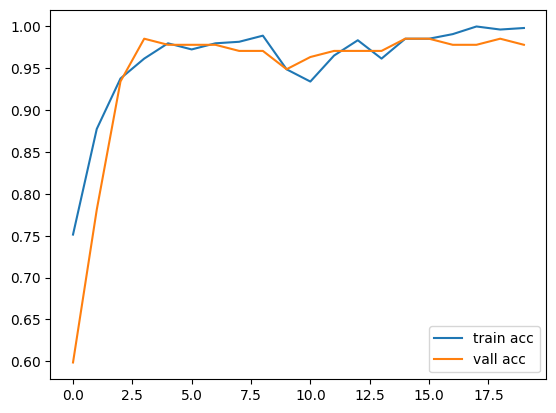

In [244]:
plt.plot(train_accs, label="train acc")
plt.plot(val_accs, label="vall acc")
plt.legend()

In [245]:
# test set

class ShapeTestDataset(Dataset):
    def __init__(self, size=20, image_size=128):
        self.size = size
        self.image_size = image_size

    def __len__(self):
        return self.size

    def __getitem__(self, index):

        random.seed(index + 1000)
        np.random.seed(index + 1000)

        image = np.random.randint(
            180,
            256,
            (self.image_size, self.image_size, 3),
            dtype=np.uint8
        )

        image = Image.fromarray(image)
        draw = ImageDraw.Draw(image)

        num_objects = random.randint(1,3)

        for _ in range(num_objects):

            cls = random.randint(1,3)

            w = random.randint(20,45)
            h = random.randint(20,45)

            xmin = random.randint(0,self.image_size-w-1)
            ymin = random.randint(0,self.image_size-h-1)

            xmax = xmin+w
            ymax = ymin+h


            color = tuple(
                random.randint(20,230)
                for _ in range(3)
            )


            if cls == 1:
                draw.rectangle(
                    [xmin,ymin,xmax,ymax],
                    fill=color
                )

            elif cls == 2:
                draw.ellipse(
                    [xmin,ymin,xmax,ymax],
                    fill=color
                )

            else:
                points = [
                    (xmin+w//2,ymin),
                    (xmin,ymax),
                    (xmax,ymax)
                ]

                draw.polygon(
                    points,
                    fill=color
                )


        image = np.array(image,dtype=np.float32)

        noise = np.random.normal(
            0,
            20,
            image.shape
        )

        image = np.clip(
            image+noise,
            0,
            255
        )


        image = torch.tensor(
            image,
            dtype=torch.float32
        )/255.


        image = image.permute(2,0,1)

        return image

In [246]:
test_dataset = ShapeTestDataset(
    size=20,
    image_size=128
)

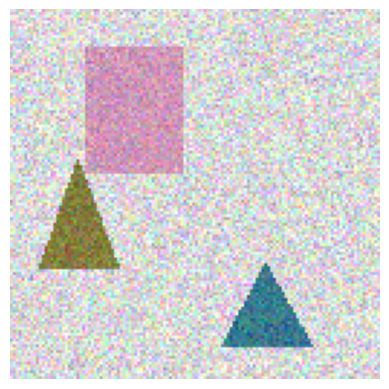

In [249]:
image = test_dataset[10]

plt.imshow(
    image.permute(1,2,0)
)
plt.axis("off")
plt.show()

In [250]:
def test_rcnn(image, model, device):

    model.eval()
    proposals = selective_search(image)
    dummy_labels = torch.zeros(
        len(proposals),
        dtype=torch.long
    )

    proposal_images, _ = crop(
        image,
        torch.tensor(proposals),
        dummy_labels
    )


    X = []

    for img in proposal_images:

        img = cv2.resize(
            img,
            (28,28)
        )

        img = torch.tensor(
            img,
            dtype=torch.float32
        )

        img = img.permute(2,0,1)

        X.append(img)


    X = torch.stack(X)


    with torch.no_grad():

        outputs = model(
            X.to(device)
        )

        preds = outputs.argmax(1).cpu()



    final_boxes = []
    final_labels = []


    for box, pred in zip(proposals, preds):

        if pred.item() != 0:

            final_boxes.append(box)
            final_labels.append(pred.item())



    show_sample(
        image,
        final_boxes,
        final_labels
    )


    return final_boxes, final_labels

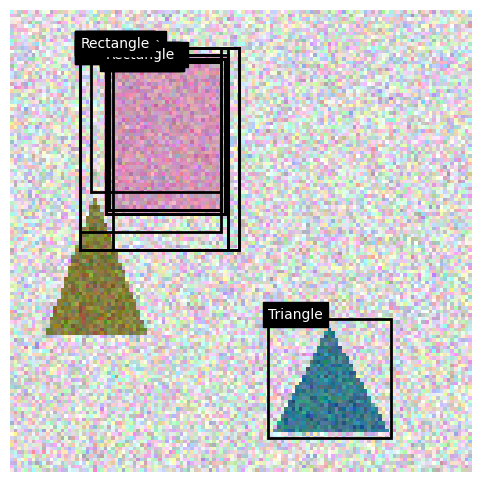

In [258]:
image = test_dataset[10]

boxes, labels = test_rcnn(
    image,
    model,
    device
)